In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns
import pickle
import sys

repo_path = "/gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/"
sys.path.append(repo_path)

import thesis.code.online_quality_and_celltype.utils as ut

In [3]:
from thesis.code.plot import plot as plotter

plotter.set_default_params(kind='paper')

# load data

In [4]:
data_dir = "/gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/thesis/data/online_quality_and_celltype"


data_dir = "/gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/thesis/data/online_quality_and_celltype"

# Load quality, traces, celltypes and online2offline mapping
with open(os.path.join(data_dir, "quality_df.pkl"), "rb") as f:
    quality_df = pickle.load(f)

with open(os.path.join(data_dir, "traces_df.pkl"), "rb") as f:
    traces_df = pickle.load(f)

with open(os.path.join(data_dir, "celltypes_df.pkl"), "rb") as f:
    celltypes_df = pickle.load(f)

with open(os.path.join(data_dir, "online2offline_celltype_df.pkl"), "rb") as f:
    online2offline_celltype_df = pickle.load(f)
with open(os.path.join(data_dir, "offline2online_celltype_df.pkl"), "rb") as f:
    offline2online_celltype_df = pickle.load(f)

with open(os.path.join(data_dir, "all_roi_masks.pkl"), "rb") as f:
    all_roi_masks = pickle.load(f)

# Print shapes to verify loading
print(f"Quality dataframe: {quality_df.shape}")
print(f"Traces dataframe: {traces_df.shape}")
print(f"Cell types dataframe: {celltypes_df.shape}")
print(f"Online to offline mapping: {online2offline_celltype_df.shape}")
print(f"Offline to online mapping: {offline2online_celltype_df.shape}")
print(f"ROI masks: {all_roi_masks.shape}")



Quality dataframe: (3873, 15)
Traces dataframe: (7748, 18)
Cell types dataframe: (3873, 18)
Online to offline mapping: (1849, 11)
Offline to online mapping: (2024, 11)
ROI masks: (40, 11)


# Visualize ROI mask differences between cond1 with cell types 

In [5]:
all_roi_masks.head(8)

,experimenter,date,exp_num,raw_id,field,region,cond1,stim_name,cond2,roi_mask,field_id
0,closedlooptest,2025-03-19,1,1,GCL1,LR,cl,gChirp,control,"[[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,...",closedlooptest_2025-03-19_1_1_GCL1_LR
1,closedlooptest,2025-03-19,1,1,GCL1,LR,n1,gChirp,control,"[[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,...",closedlooptest_2025-03-19_1_1_GCL1_LR
2,closedlooptest,2025-03-19,2,1,GCL1,RR,cl,gChirp,control,"[[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,...",closedlooptest_2025-03-19_2_1_GCL1_RR
3,closedlooptest,2025-03-19,2,1,GCL1,RR,n1,gChirp,control,"[[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,...",closedlooptest_2025-03-19_2_1_GCL1_RR
4,closedlooptest,2025-03-19,2,1,GCL3,RR,cl,gChirp,control,"[[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,...",closedlooptest_2025-03-19_2_1_GCL3_RR
5,closedlooptest,2025-03-19,2,1,GCL3,RR,n1,gChirp,control,"[[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,...",closedlooptest_2025-03-19_2_1_GCL3_RR
6,closedlooptest,2025-03-19,2,1,GCL4,RR,cl,gChirp,control,"[[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,...",closedlooptest_2025-03-19_2_1_GCL4_RR
7,closedlooptest,2025-03-19,2,1,GCL4,RR,n1,gChirp,control,"[[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,...",closedlooptest_2025-03-19_2_1_GCL4_RR


In [7]:
mask = (all_roi_masks["date"] == "2025-03-19") & \
            (all_roi_masks["exp_num"] == 1) & \
            (all_roi_masks["field"] == "GCL1")
all_roi_masks[mask].head(8)

,experimenter,date,exp_num,raw_id,field,region,cond1,stim_name,cond2,roi_mask,field_id
0,closedlooptest,2025-03-19,1,1,GCL1,LR,cl,gChirp,control,"[[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,...",closedlooptest_2025-03-19_1_1_GCL1_LR
1,closedlooptest,2025-03-19,1,1,GCL1,LR,n1,gChirp,control,"[[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,...",closedlooptest_2025-03-19_1_1_GCL1_LR


In [32]:
celltypes_per_roi = celltypes_df.merge(all_roi_masks[mask],on=["date", "exp_num", "field","cond1"], how="inner")[["cond1", "celltype","roi_id"]]
celltypes_per_roi.head(8)

,cond1,celltype,roi_id
0,cl,17,1
1,cl,27,2
2,cl,43,3
3,cl,31,4
4,cl,32,5
5,cl,42,6
6,cl,44,7
7,cl,2,8


In [33]:
celltypes_per_roi["celltype"].value_counts()

celltype
43    64
42    45
28    12
22     8
1      8
36     7
32     5
2      5
12     4
38     4
27     4
17     4
6      4
4      3
44     2
31     2
41     2
5      2
11     2
29     1
26     1
14     1
30     1
21     1
Name: count, dtype: int64

In [26]:
from djimaging.utils.mask_format_utils import as_python_format
from djimaging.utils.image_utils import color_image
from model_in_the_loop.core.gui.ExtendedAutoRoiGui import load_stack_data

files = ["/gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/thesis/data/online_quality_and_celltype/data_dj_format/20250319/1/Raw/M1_LR_GCL1_chirp_cl.smh"]

stacks = load_stack_data(
    files = files,
    data_name = "ch_0",
    alt_name="ch_1",
    from_raw_data=True,
)


In [30]:
from matplotlib.colors import to_rgba
from matplotlib.patches import Patch

RGC_GROUP_GROUP_ID_TO_CLASS_NAME = (
    {i: "OFF" for i in range(1, 10)}
    | {i: "ON-OFF" for i in range(10, 15)}
    | {i: "Fast ON" for i in range(15, 21)}
    | {i: "SLOW ON" for i in range(21, 29)}
    | {i: "Uncertain RGC" for i in range(29, 33)}
    | {i: "AC" for i in range(33, 47)}
)
CLASS_NAME_TO_COLOR = {
"OFF": "red",
"ON-OFF": "green",
"Fast ON": "turquoise",
"SLOW ON": "blue",
"Uncertain RGC": "violet",
"AC": "white",
}

def show_roi_mask_roi_color(roi_mask,
                            roi2color,ax = None,add_boundary=True):
    """
    plots roi mask with roi colored according to roi2color mapping
    """
    if ax is None:
        _, ax = plt.subplots(1, 1, figsize=(4, 4))

    mask = np.asarray(roi_mask, dtype=int)
    if mask.ndim != 2:
        raise ValueError(f"roi_mask must be 2D, got shape {mask.shape}")

    mask = np.abs(mask)
    roi_ids_in_mask = np.unique(mask)
    roi_ids_in_mask = roi_ids_in_mask[roi_ids_in_mask > 1]

    missing_roi_ids = sorted(set(roi_ids_in_mask.tolist()) - set(roi2color.keys()))
    if missing_roi_ids:
        raise ValueError(
            "Missing ROI colors for ROI IDs present in roi_mask (excluding background): "
            f"{missing_roi_ids}"
        )

    rgba_img = np.ones((*mask.shape, 4), dtype=float)
    rgba_img[..., 3] = 0.0

    for roi_id in roi_ids_in_mask:
        roi_pixels = mask == roi_id
        rgba_img[roi_pixels] = to_rgba(roi2color[int(roi_id)], alpha=1.0)
    if add_boundary:
        non_bg = mask > 1
        boundary = np.zeros_like(non_bg, dtype=bool)
        boundary[1:, :] |= non_bg[1:, :] & (mask[1:, :] != mask[:-1, :])
        boundary[:-1, :] |= non_bg[:-1, :] & (mask[:-1, :] != mask[1:, :])
        boundary[:, 1:] |= non_bg[:, 1:] & (mask[:, 1:] != mask[:, :-1])
        boundary[:, :-1] |= non_bg[:, :-1] & (mask[:, :-1] != mask[:, 1:])

        rgba_img[boundary, :3] = (0.0, 0.0, 0.0)
        rgba_img[boundary, 3] = 1.0

    ax.imshow(rgba_img, origin="lower", interpolation="none")
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])
    return ax

def get_roi2color(roi_ids,celltypes):
    """
    returns a mapping from roi_id to color based on celltype
    """
    roi_ids_arr = np.asarray(roi_ids).reshape(-1)
    celltypes_arr = np.asarray(celltypes).reshape(-1)

    if roi_ids_arr.size == 0 or celltypes_arr.size == 0:
        raise ValueError("roi_ids and celltypes must be non-empty")
    if roi_ids_arr.size != celltypes_arr.size:
        raise ValueError(
            f"roi_ids and celltypes must have same length, got {roi_ids_arr.size} and {celltypes_arr.size}"
        )

    try:
        roi_ids_int = np.asarray([int(x) for x in roi_ids_arr], dtype=int)
        celltypes_int = np.asarray([int(x) for x in celltypes_arr], dtype=int)
    except Exception as exc:
        raise ValueError("roi_ids and celltypes must be integer-compatible") from exc

    unique_roi_ids, counts = np.unique(roi_ids_int, return_counts=True)
    duplicate_roi_ids = unique_roi_ids[counts > 1]
    if duplicate_roi_ids.size > 0:
        raise ValueError(f"Duplicate roi_id values found: {duplicate_roi_ids.tolist()}")

    roi2color = {}
    for roi_id, celltype in zip(roi_ids_int, celltypes_int):
        if celltype not in RGC_GROUP_GROUP_ID_TO_CLASS_NAME:
            raise ValueError(f"Unknown celltype group id: {celltype}")
        class_name = RGC_GROUP_GROUP_ID_TO_CLASS_NAME[celltype]
        if class_name not in CLASS_NAME_TO_COLOR:
            raise KeyError(f"Missing class-to-color mapping for class: {class_name}")
        roi2color[int(roi_id)] = CLASS_NAME_TO_COLOR[class_name]

    return roi2color

def plot_celltype_legend(labels,colors,ax,):
    """
    plots a legend for celltypes with given labels and colors
    """
    if len(labels) != len(colors):
        raise ValueError(f"labels and colors must have same length, got {len(labels)} and {len(colors)}")

    handles = [
        Patch(facecolor=color, edgecolor="black", label=label)
        for label, color in zip(labels, colors)
    ]
    ax.axis("off")
    ax.legend(handles=handles, loc=(1,1))
    return ax


def plot_roi_mask_roi_color_comparison(all_roi_masks,celltypes_df,mask):
    """
    Plots the roi mask with roi colored according to celltype for a given mask
    """
    required_mask_cols = {"date", "exp_num", "field", "cond1", "roi_mask"}
    missing_mask_cols = sorted(required_mask_cols - set(all_roi_masks.columns))
    if missing_mask_cols:
        raise KeyError(f"all_roi_masks missing required columns: {missing_mask_cols}")

    required_celltype_cols = {"date", "exp_num", "field", "cond1", "roi_id", "celltype"}
    missing_celltype_cols = sorted(required_celltype_cols - set(celltypes_df.columns))
    if missing_celltype_cols:
        raise KeyError(f"celltypes_df missing required columns: {missing_celltype_cols}")

    selected_roi_masks = all_roi_masks.loc[mask].copy()
    if selected_roi_masks.empty:
        raise ValueError("Mask selection returned no rows in all_roi_masks")

    roi_mask_counts_per_cond1 = selected_roi_masks.groupby("cond1").size()
    non_unique_cond1 = roi_mask_counts_per_cond1[roi_mask_counts_per_cond1 != 1]
    if not non_unique_cond1.empty:
        raise ValueError(
            "Expected exactly one roi_mask row per cond1, found: "
            f"{non_unique_cond1.to_dict()}"
        )

    merge_keys = ["date", "exp_num", "field", "cond1"]
    selected_celltypes = celltypes_df.merge(
        selected_roi_masks[merge_keys],
        on=merge_keys,
        how="inner",
    )[["cond1", "celltype", "roi_id"]].copy()

    if selected_celltypes.empty:
        raise ValueError("No celltype rows matched the selected roi_mask rows")

    duplicate_roi_per_cond1 = selected_celltypes.groupby(["cond1", "roi_id"]).size()
    duplicate_roi_per_cond1 = duplicate_roi_per_cond1[duplicate_roi_per_cond1 > 1]
    if not duplicate_roi_per_cond1.empty:
        raise ValueError(
            "Duplicate roi_id values found within cond1 groups: "
            f"{duplicate_roi_per_cond1.to_dict()}"
        )

    cond1_values = sorted(selected_roi_masks["cond1"].unique().tolist())
    cond1_with_celltypes = set(selected_celltypes["cond1"].unique().tolist())
    missing_cond1_celltypes = [cond1 for cond1 in cond1_values if cond1 not in cond1_with_celltypes]
    if missing_cond1_celltypes:
        raise ValueError(f"Missing celltypes for cond1 values: {missing_cond1_celltypes}")

    n_cond1 = len(cond1_values)
    fig, axes = plt.subplots(1, n_cond1 + 1, figsize=(4 * (n_cond1 + 1), 4))
    axes = np.atleast_1d(axes)

    for i, cond1 in enumerate(cond1_values):
        cond1_mask = selected_roi_masks["cond1"] == cond1
        cond1_roi_mask = np.asarray(selected_roi_masks.loc[cond1_mask, "roi_mask"].iloc[0], dtype=int)
        cond1_celltypes = selected_celltypes[selected_celltypes["cond1"] == cond1]

        roi2color = get_roi2color(
            cond1_celltypes["roi_id"].to_numpy(),
            cond1_celltypes["celltype"].to_numpy(),
        )
        show_roi_mask_roi_color(cond1_roi_mask, roi2color, ax=axes[i])
        axes[i].set_title(f"cond1={cond1}")

    legend_labels = ["OFF", "ON-OFF", "Fast ON", "SLOW ON", "Uncertain RGC", "AC"]
    legend_colors = [CLASS_NAME_TO_COLOR[label] for label in legend_labels]
    plot_celltype_legend(legend_labels, legend_colors, ax=axes[-1])

    field_info = selected_roi_masks.iloc[0]
    fig.suptitle(
        f"date={field_info['date']}, exp_num={field_info['exp_num']}, field={field_info['field']}",
        fontsize=11,
    )
    fig.tight_layout(rect=(0.0, 0.0, 1.0, 0.95))
    return fig, axes


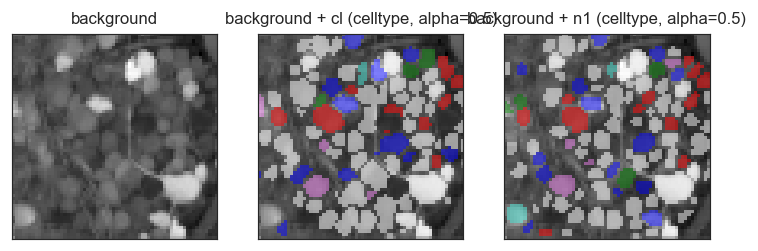

In [ ]:
ch0_mean = np.mean(stacks[0][0], axis=2)
bg_img = color_image(ch0_mean, cmap="gray", gamma=0.33, alpha=255)

# Tunable plotting settings
mask_alpha = 0.5
rotate_masks_ccw = False

required_mask_cols = {"cond1", "roi_mask", "date", "exp_num", "field"}
missing_mask_cols = sorted(required_mask_cols - set(all_roi_masks.columns))
if missing_mask_cols:
    raise KeyError(f"all_roi_masks missing required columns: {missing_mask_cols}")

required_celltype_cols = {"date", "exp_num", "field", "cond1", "roi_id", "celltype"}
missing_celltype_cols = sorted(required_celltype_cols - set(celltypes_df.columns))
if missing_celltype_cols:
    raise KeyError(f"celltypes_df missing required columns: {missing_celltype_cols}")

selected_roi_masks = all_roi_masks.loc[mask, ["cond1", "roi_mask", "date", "exp_num", "field"]].copy()
if selected_roi_masks.empty:
    raise ValueError("Mask selection returned no rows in all_roi_masks")

required_cond1 = {"n1", "cl"}
found_cond1 = set(selected_roi_masks["cond1"].tolist())
missing_cond1 = sorted(required_cond1 - found_cond1)
if missing_cond1:
    raise ValueError(f"Missing required cond1 masks: {missing_cond1}")

selected_roi_masks = selected_roi_masks[selected_roi_masks["cond1"].isin(["n1", "cl"])].copy()
roi_mask_counts = selected_roi_masks.groupby("cond1").size()
non_unique = roi_mask_counts[roi_mask_counts != 1]
if not non_unique.empty:
    raise ValueError(f"Expected exactly one roi_mask row per cond1, found: {non_unique.to_dict()}")

merge_keys = ["date", "exp_num", "field", "cond1"]
selected_celltypes = celltypes_df.merge(
    selected_roi_masks[merge_keys].drop_duplicates(),
    on=merge_keys,
    how="inner",
)[["cond1", "roi_id", "celltype"]].copy()
if selected_celltypes.empty:
    raise ValueError("No celltype rows matched selected roi_mask rows")

dup_roi = selected_celltypes.groupby(["cond1", "roi_id"]).size()
dup_roi = dup_roi[dup_roi > 1]
if not dup_roi.empty:
    raise ValueError(f"Duplicate roi_id values found within cond1 groups: {dup_roi.to_dict()}")

bg_hw = bg_img.shape[:2]
roi_masks = {}
roi2colors = {}
for cond1 in ["n1", "cl"]:
    cond_mask = np.asarray(
        selected_roi_masks.loc[selected_roi_masks["cond1"] == cond1, "roi_mask"].iloc[0],
        dtype=int,
    )
    if rotate_masks_ccw:
        cond_mask = np.rot90(cond_mask, k=1)
    if cond_mask.shape != bg_hw:
        raise ValueError(
            f"Shape mismatch for cond1={cond1}: roi_mask shape {cond_mask.shape} does not match background shape {bg_hw}"
        )
    roi_masks[cond1] = cond_mask

    cond_celltypes = selected_celltypes[selected_celltypes["cond1"] == cond1]
    roi2colors[cond1] = get_roi2color(
        roi_ids=cond_celltypes["roi_id"].to_numpy(),
        celltypes=cond_celltypes["celltype"].to_numpy(),
    )

fig, axes = plt.subplots(1, 3, figsize=plotter.figsize_from_frac(1, 1/3))

axes[0].imshow(bg_img, origin="lower")
axes[0].set_title("background")


axes[1].imshow(bg_img, origin="lower")
show_roi_mask_roi_color(roi_masks["cl"], roi2colors["cl"], ax=axes[1],add_boundary=False)
axes[1].images[-1].set_alpha(mask_alpha)
axes[1].set_title(f"background + cl (celltype, alpha={mask_alpha})")

axes[2].imshow(bg_img, origin="lower")
show_roi_mask_roi_color(roi_masks["n1"], roi2colors["n1"], ax=axes[2],add_boundary=False)
axes[2].images[-1].set_alpha(mask_alpha)
axes[2].set_title(f"background + n1 (celltype, alpha={mask_alpha})")

# legend_labels = ["OFF", "ON-OFF", "Fast ON", "SLOW ON", "Uncertain RGC", "AC"]
# legend_colors = [CLASS_NAME_TO_COLOR[label] for label in legend_labels]
# plot_celltype_legend(legend_labels, legend_colors, ax=axes[-1])
# fig.tight_layout(rect=(0.0, 0.0, .7, 0.95))


for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])

fig.savefig(os.path.join("/gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/thesis/figures/presentation", "background_masks_supertypes.svg"),format="svg",)



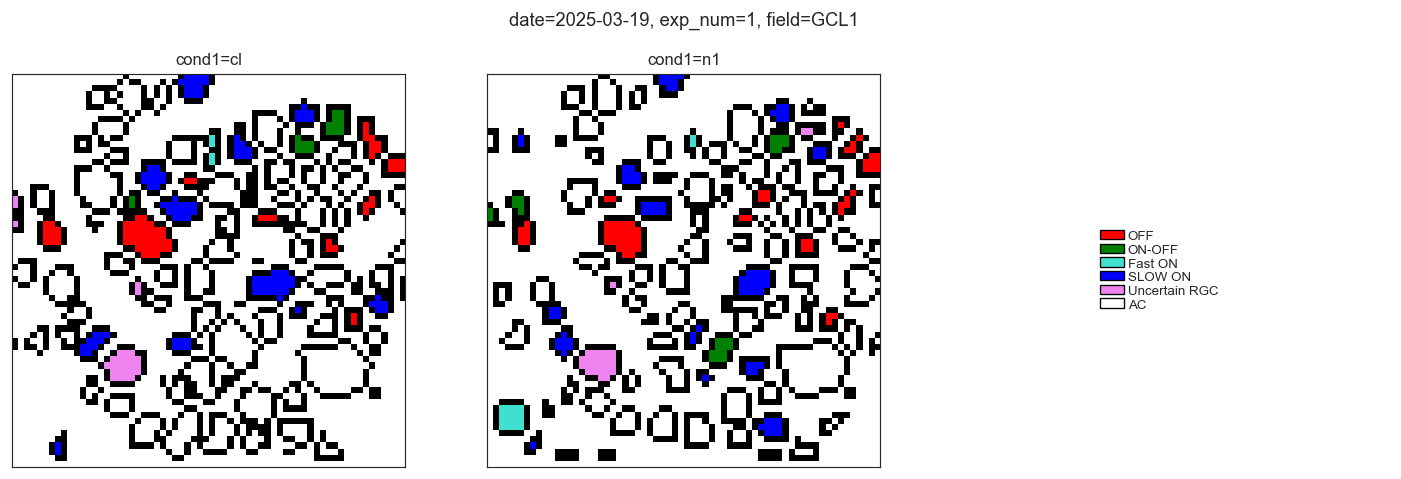

In [32]:
mask_example = (
    (all_roi_masks["date"] == "2025-03-19")
    & (all_roi_masks["exp_num"] == 1)
    & (all_roi_masks["field"] == "GCL1")
)

fig, axes = plot_roi_mask_roi_color_comparison(
    all_roi_masks=all_roi_masks,
    celltypes_df=celltypes_df,
    mask=mask_example,
)
plt.show()


In [ ]:
print(f"nr unique date exp retian combinations: {quality_df.groupby(["date","exp_num","region" ]).size().shape}")
print(f"Nr unique date, exp num, region, field combinaitons {quality_df.groupby(["date","exp_num","region","field" ]).size().shape}")


nr unique date exp retian combinations: (6,)
Nr unique date, exp num, region, field combinaitons (20,)


# Simulation calculation

In [12]:
sim_save_path = "/gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/thesis/figures/online_quality_and_celltype"

In [13]:
from thesis.code.online_quality_and_celltype.simulation import wrapper_sim,get_all_sim_data


# get sim data
C, prob_types = get_all_sim_data(offline2online_celltype_df)
print(C.shape)

print(prob_types.shape)
results = wrapper_sim(target=list(range(32)), C=C, prob_type=prob_types,)
results.head()
print(f"Median percentage gain: {results['percentage_gain'].median():.2f}%")

(33, 34)
(33,)
Median percentage gain: 12.03%


In [24]:
prob_types

array([0.01976285, 0.00988142, 0.006917  , 0.0222332 , 0.00741107,
       0.00790514, 0.00988142, 0.00049407, 0.00098814, 0.0034585 ,
       0.04397233, 0.02618577, 0.00592885, 0.03458498, 0.00049407,
       0.00494071, 0.09436759, 0.01136364, 0.00049407, 0.00839921,
       0.01581028, 0.05583004, 0.03507905, 0.00148221, 0.        ,
       0.01136364, 0.01482213, 0.01037549, 0.00543478, 0.01037549,
       0.04100791, 0.13537549, 0.34337945])

In [31]:
# some summary stats

# median hit rate per cell type (or AC)
print( f"Mean hit rate {np.mean(np.diag(C).reshape(-1,1))}" )



Mean hit rate 0.5830283250582877


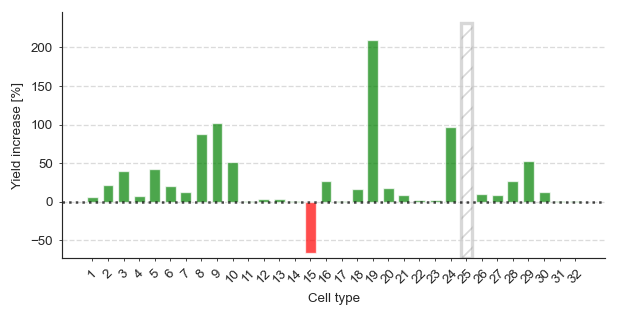

In [14]:
fig,ax = ut.plot_percentage_gain(results,
                                 subplots_kws = {'figsize': plotter.figsize_from_frac(2/3,1/3)},
                                plt_kws = {},
                                open_bar_celltypes = [25]
)

plotter.tight_layout()

# save
fig.savefig(os.path.join(sim_save_path, "percentage_gain_online_vs_offline_celltype.svg"))


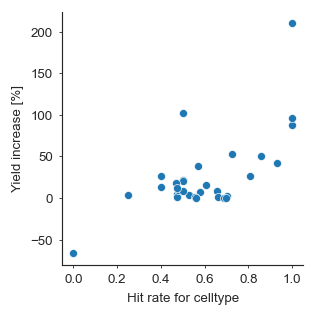

In [15]:
fig,ax = plt.subplots(figsize=plotter.figsize_from_frac(1/3,1/3))

sns.scatterplot(data=results, x="target_hit_prob", y="percentage_gain",ax = ax)
sns.despine()
ax.set_xlabel("Hit rate for celltype")
ax.set_ylabel("Yield increase [%]")
plotter.tight_layout()

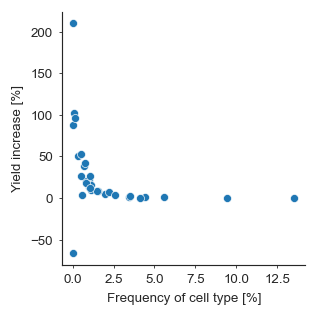

In [16]:

results["target_fraction_percent"] = results["target_fraction"] * 100
fig,ax = plt.subplots(figsize=plotter.figsize_from_frac(1/3,1/3))

sns.scatterplot(data=results, x="target_fraction_percent", y="percentage_gain",ax = ax)
sns.despine()
# ax.set_xscale("log")
ax.set_xlabel("Frequency of cell type [%]")
ax.set_ylabel("Yield increase [%]")
plotter.tight_layout()
fig_namesave = os.path.join(sim_save_path, "percentage_gain_vs_frequency_celltype.svg")
fig.savefig(fig_namesave,format="svg")

### figure yield increase vs frquency

# figures

## quality

In [17]:
quality_pivot = ut.apply_func_and_pivot(quality_df,func=ut.frac_passing_or)




/gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/thesis/code/online_quality_and_celltype/utils.py:59: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ).apply(func,).reset_index()


Correlation between online and offline quality: 0.960


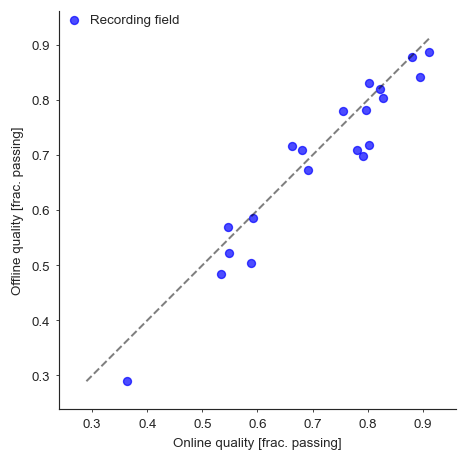

In [18]:
fig,ax = ut.plot_quality_scatter(quality_pivot,
                                 subplot_kws = {'figsize': plotter.figsize_from_frac(0.5,0.5)},
    scatter_kws = {'color':'blue'},
)
plotter.tight_layout()

ax.set_xlabel("Online quality [frac. passing]")
ax.set_ylabel("Offline quality [frac. passing]")

# save
fig.savefig(os.path.join(sim_save_path, "quality_offline_vs_online_scatter_frac_passing.svg"))

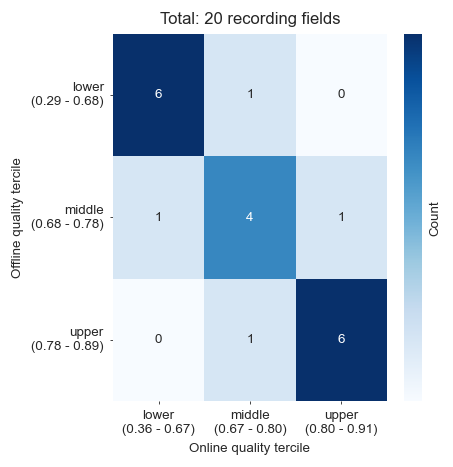

In [13]:
fig,ax =ut.plot_ballpark_quality_contingency(quality_pivot,
                                             subplot_kws = {'figsize': plotter.figsize_from_frac(0.5,0.5)},
                                         heatmap_kws = {},
)
plotter.tight_layout()

# save
fig.savefig(os.path.join(sim_save_path, "quality_offline_online_contingengy_table_frac_passing.svg"))

## Celltype

In [14]:
ct_save_dir = "/gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/thesis/figures/online_quality_and_celltype"

### contingcy table and conditional probability table heatplot

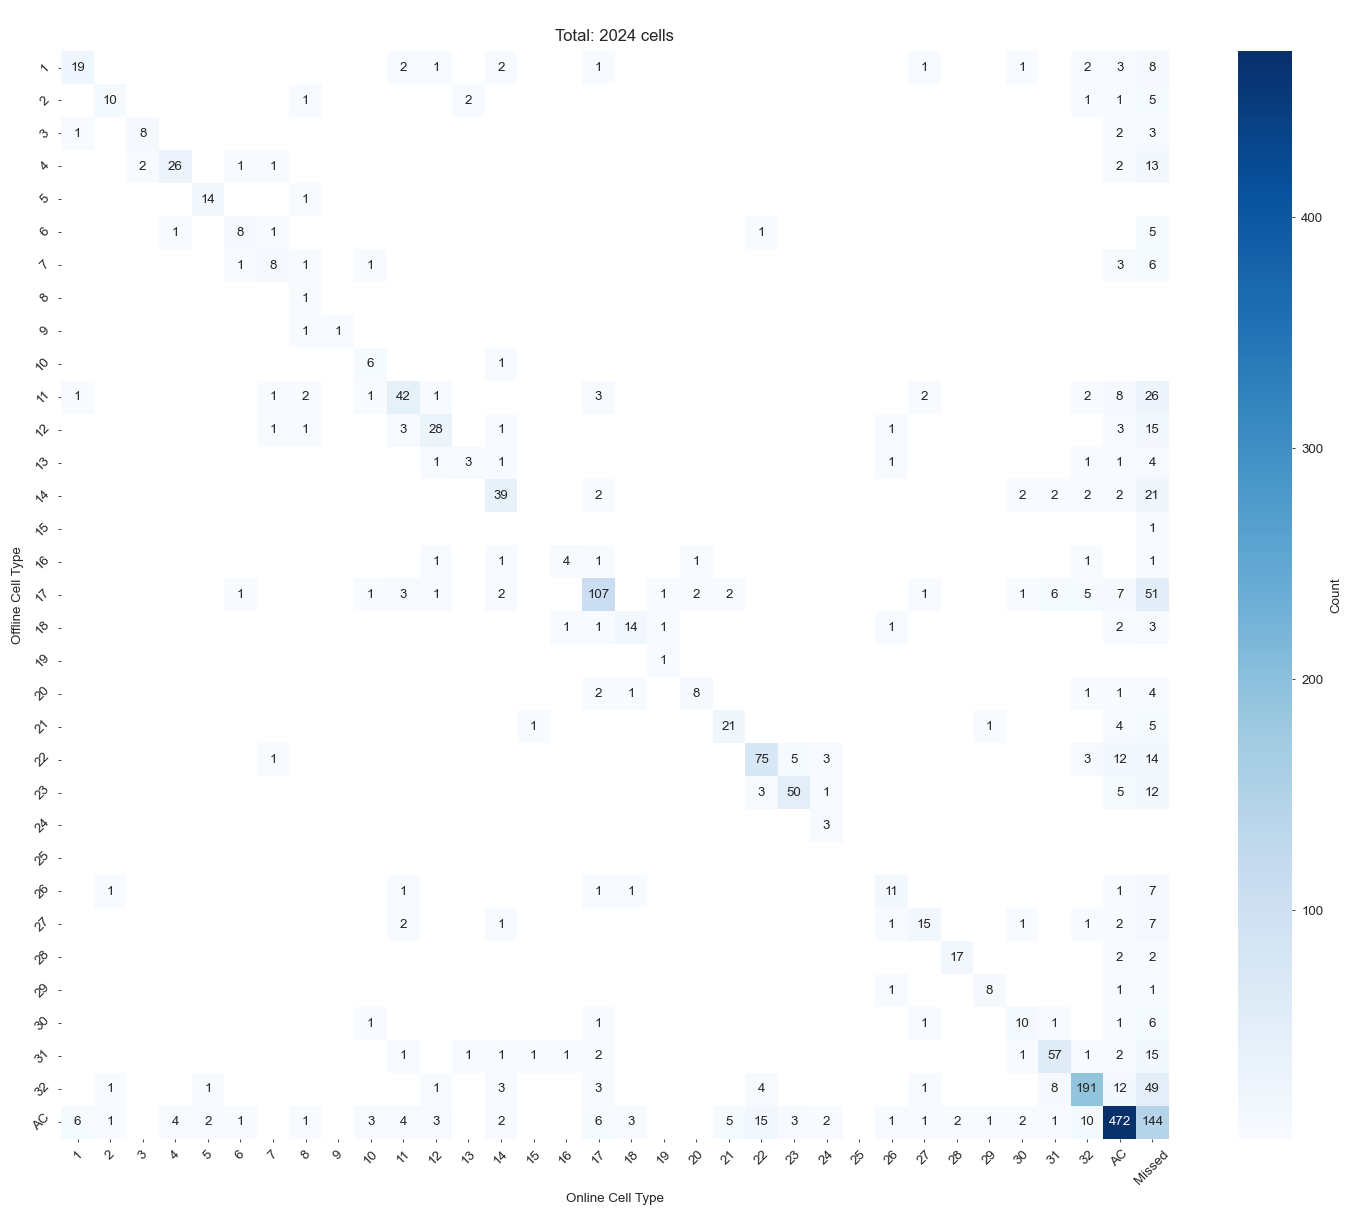

In [15]:
fig,ax = ut.plot_celltype_confusion_matrix(
    df=offline2online_celltype_df,
    offline_col='offline_cell_type',
    online_col='online_cell_type',
    max_type=32,
    figsize=(12,10),
    nan_strategy='group',
    )#heatmap_kws={'vmin':0,'vmax':400})

plotter.tight_layout()

# save
fig.savefig(os.path.join(ct_save_dir, "offline2online_celltype_confusion_matrix_count.svg"))

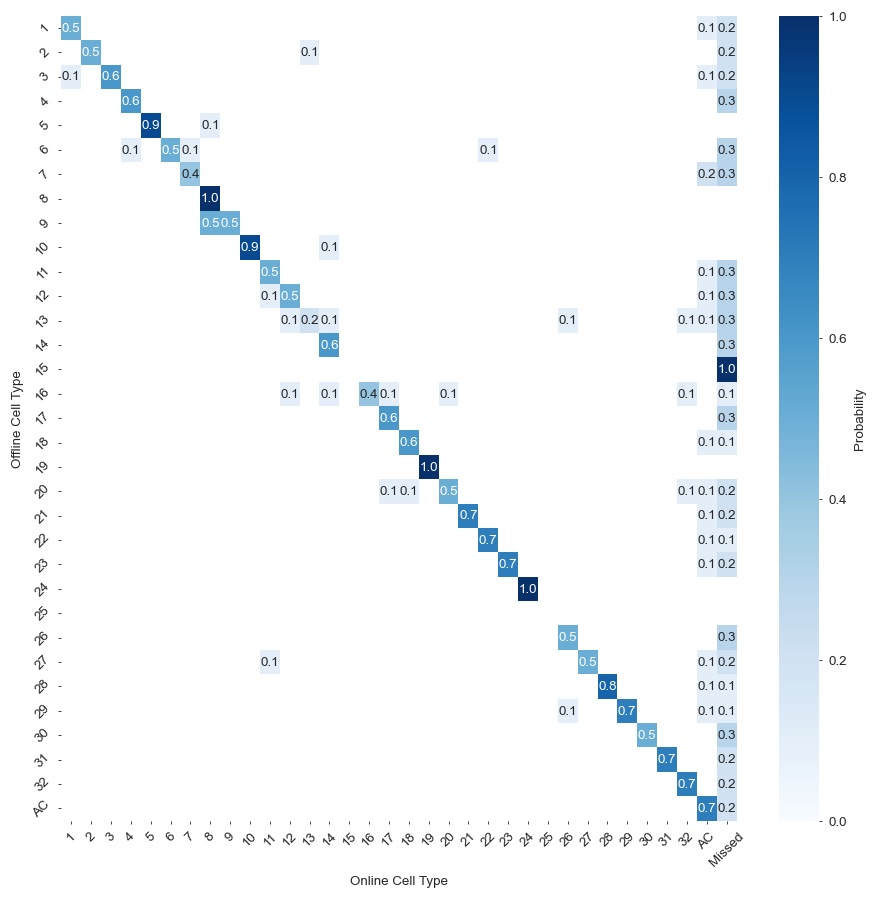

In [16]:
fig,ax = ut.plot_celltype_confusion_matrix(
    df=offline2online_celltype_df,
    offline_col='offline_cell_type',
    online_col='online_cell_type',
    max_type=32,
    figsize=plotter.figsize_from_frac(1,1),
    plot_counts=False,
    annot_fmt='.1f',
    round_to=1,
    nan_strategy='group',
    heatmap_kws={'vmin':0.0,'vmax':1})

# # Fix the annotations after creating the heatmap
# for text in ax.texts:
#     current_text = text.get_text()
#     if current_text.startswith('0.'):
#         if current_text != '0.0':
#             text.set_text(current_text.replace('0.', '.'))
#         else:
#             text.remove()

plotter.tight_layout()
ax.set_title("")
# save
fig.savefig(os.path.join(ct_save_dir, "offline2online_celltype_confusion_matrix_probability.svg"))

Text(0.5, 1.0, '')

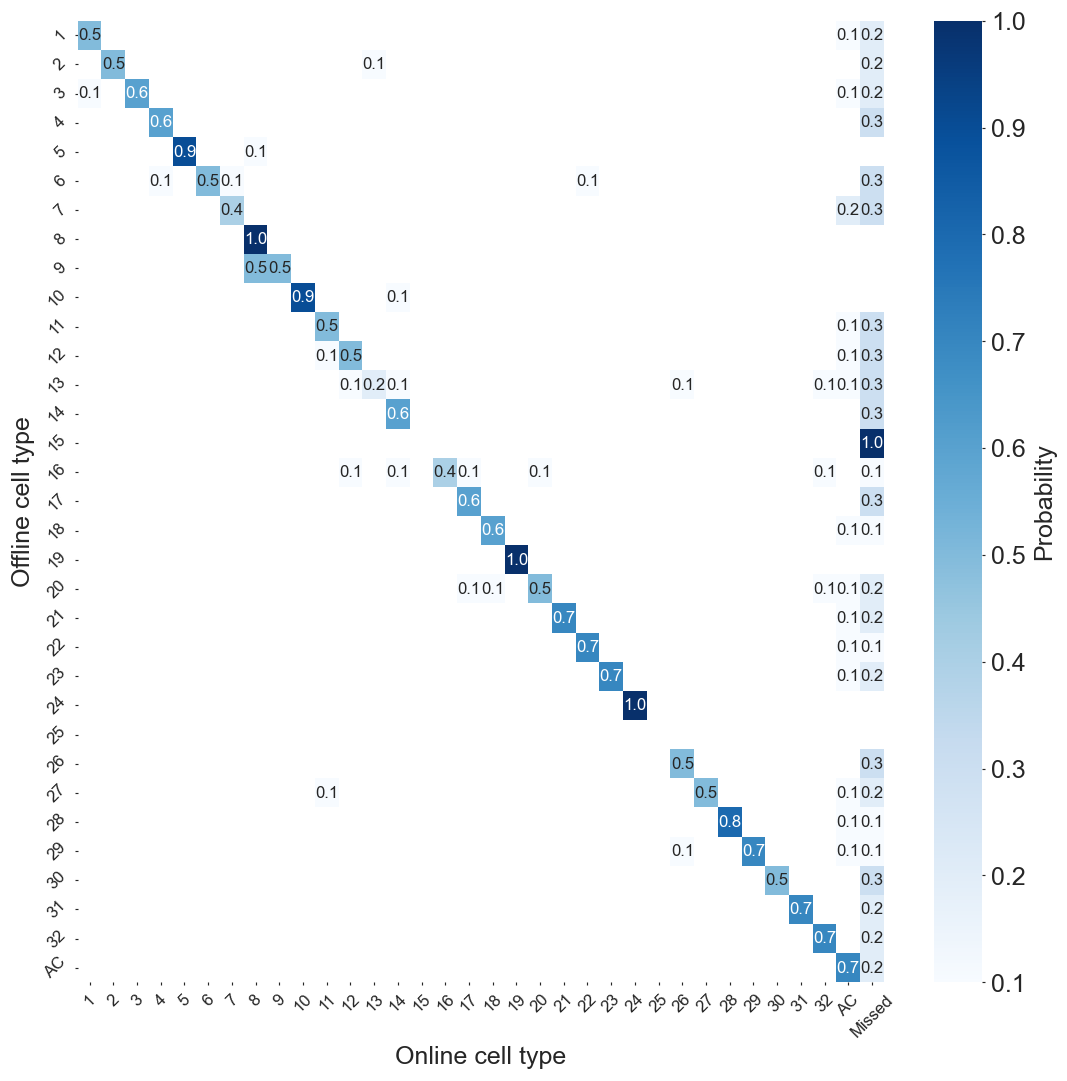

In [41]:
# presentation style
plotter.set_default_params(kind='talk')
fs = 15

fig,ax = ut.plot_celltype_confusion_matrix(
    df=offline2online_celltype_df,
    offline_col='offline_cell_type',
    online_col='online_cell_type',
    max_type=32,
    figsize=plotter.figsize_from_frac(1.2,1.2),
    plot_counts=False,
    annot_fmt='.1f',
    round_to=1,
    nan_strategy='group',
    
    )

# # Fix the annotations after creating the heatmap
# for text in ax.texts:
#     current_text = text.get_text()
#     if current_text.startswith('0.'):
#         if current_text != '0.0':
#             text.set_text(current_text.replace('0.', '.'))
#         else:
#             text.remove()


# increase xy label font size
ax.set_xlabel("Online cell type", fontsize=fs)
ax.set_ylabel("Offline cell type", fontsize=fs)

# # increase cmap fontsize
# Modify colorbar font sizes after plotting
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=fs)  # Change tick label size
cbar.set_label('Probability', size=fs)  # Change colorbar label size


plotter.tight_layout()
ax.set_title("")
# save
#fig.savefig(os.path.join(ct_save_dir, "offline2online_celltype_confusion_matrix_probability_presentation.jpg"))